## Environment setup

In [1]:
from datetime import datetime 
import importlib
from functools import partial

import tensorflow as tf
from tensorflow.data import Dataset, TFRecordDataset
import tensorflow_datasets as tfds

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns

# Notebooks run from VSCode use home directory as a base path
# while notebooks run from JupyterLab use the current directory as a base path
import sys
sys.path.append("/home/akalinow/scratch/ELITPC/TPCReco/PythonAnalysis/python/")

# Change directory to the working directory
import os
os.chdir('/home/marcel/Desktop/work/work_dir/') # my working dir

#Increase plots font size
params = {'legend.fontsize': 'xx-large',
          'figure.figsize': (10, 7),
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

2025-07-22 21:02:45.207710: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-22 21:02:45.228162: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-22 21:02:45.228195: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-22 21:02:45.240598: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Load dataset and convert to pandas DataFrame

In [ ]:
%%time 

import utility_functions as utils
importlib.reload(utils)

dataset = tf.data.Dataset.load('MergedEvent_Track3D_TwoProng_gun_MC', compression="GZIP")

data = dataset.map(lambda x: tf.reshape(x["sim"][1], (1,-1))).unbatch().as_numpy_iterator()
df = pd.DataFrame(data, columns=utils.columnsXYZ)

data = dataset.map(lambda x: tf.reshape(x["reco"][1], (1,-1))).unbatch().as_numpy_iterator()
df_reco = pd.DataFrame(data, columns=utils.columnsXYZ)

df = df.merge(df_reco, left_index=True, right_index=True, suffixes=("_sim", "_reco"), how="outer");

Cause: could not parse the source code of <function <lambda> at 0x7193e6c723e0>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function <lambda> at 0x7193e6c723e0>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7192f615ca40>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function <lambda> at 0x7192f615ca40>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


2025-07-22 21:36:03.578910: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


CPU times: user 5.61 s, sys: 80 ms, total: 5.69 s
Wall time: 5.35 s


2025-07-22 21:36:06.241407: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [7]:
df_dir = '/home/marcel/Desktop/work/work_dir/df_dir'
filename = 'df_merged.pkl'

os.makedirs(df_dir, exist_ok=True)

filepath = os.path.join(df_dir, filename)

df.to_pickle(filepath)

### Resolution plots

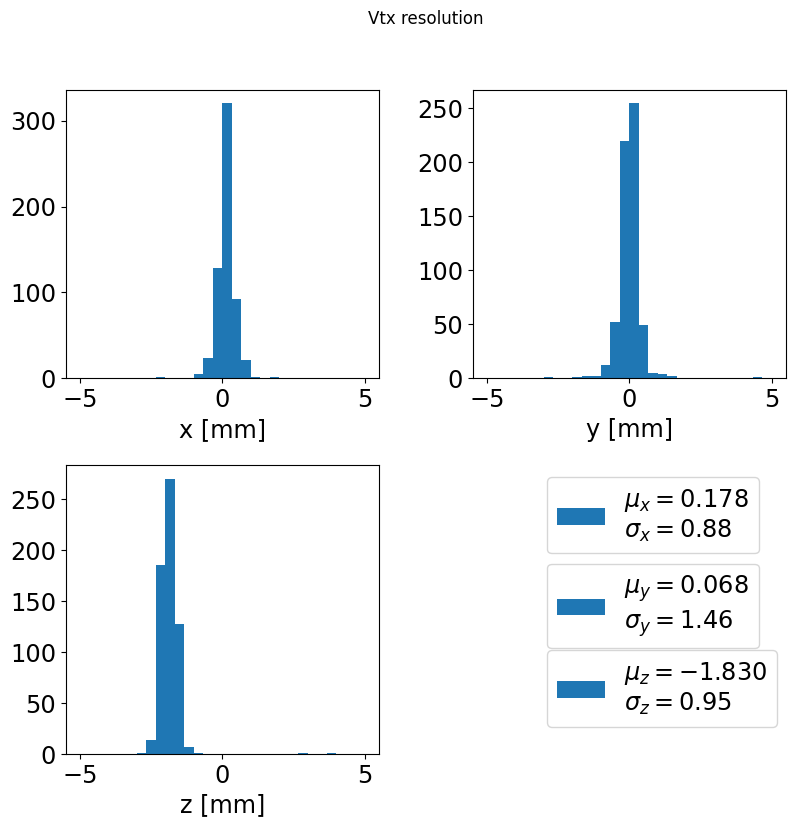

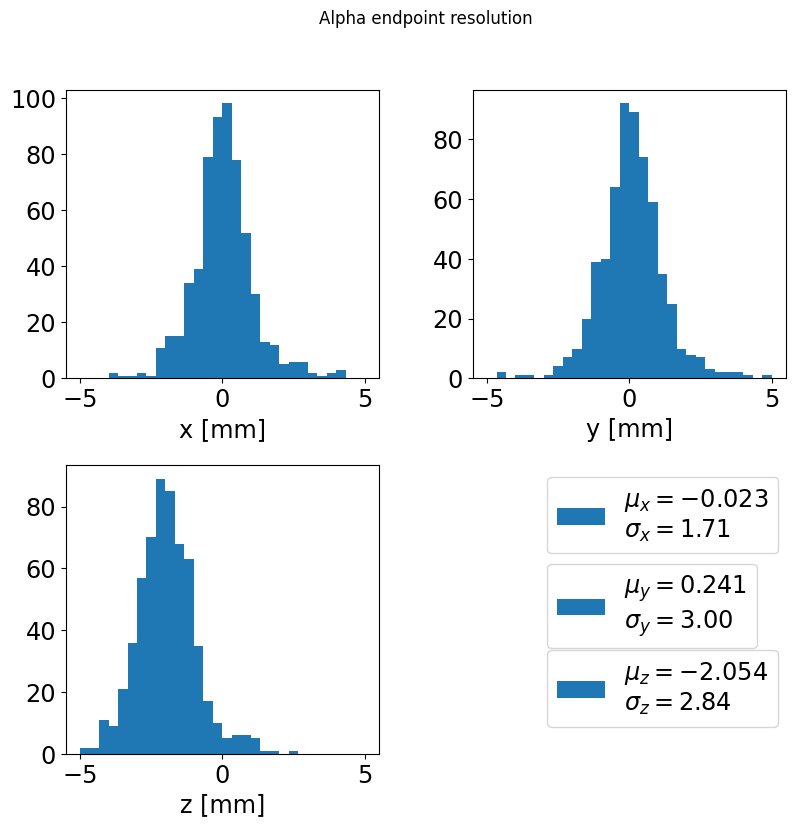

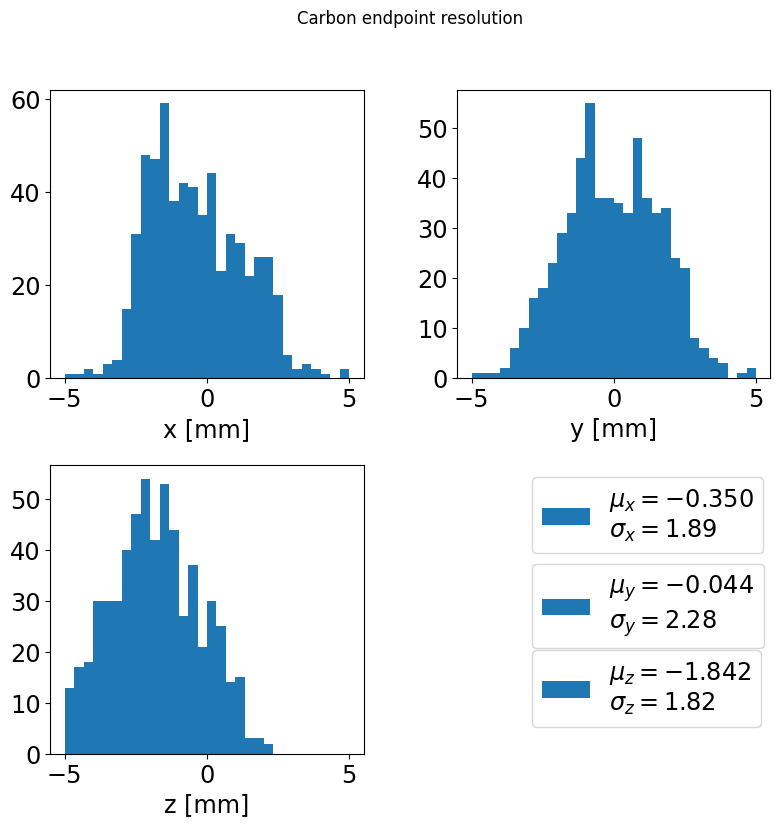

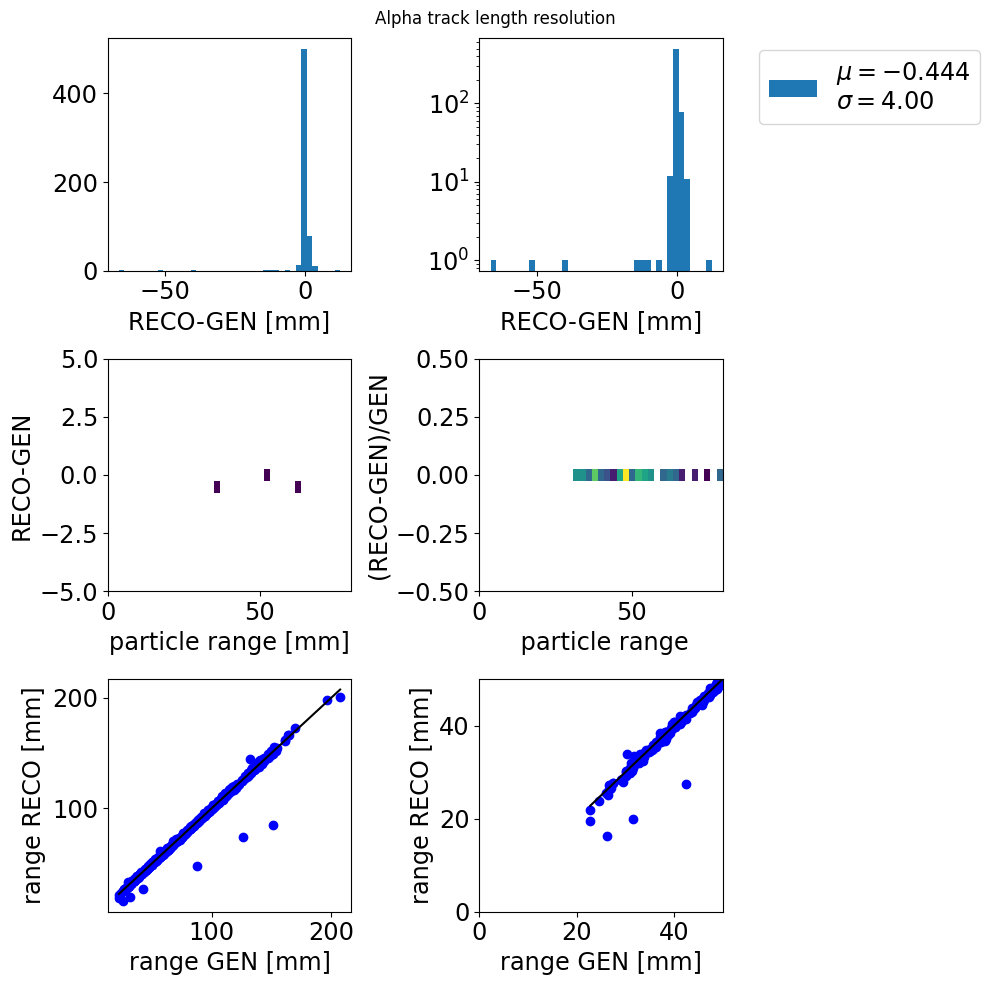

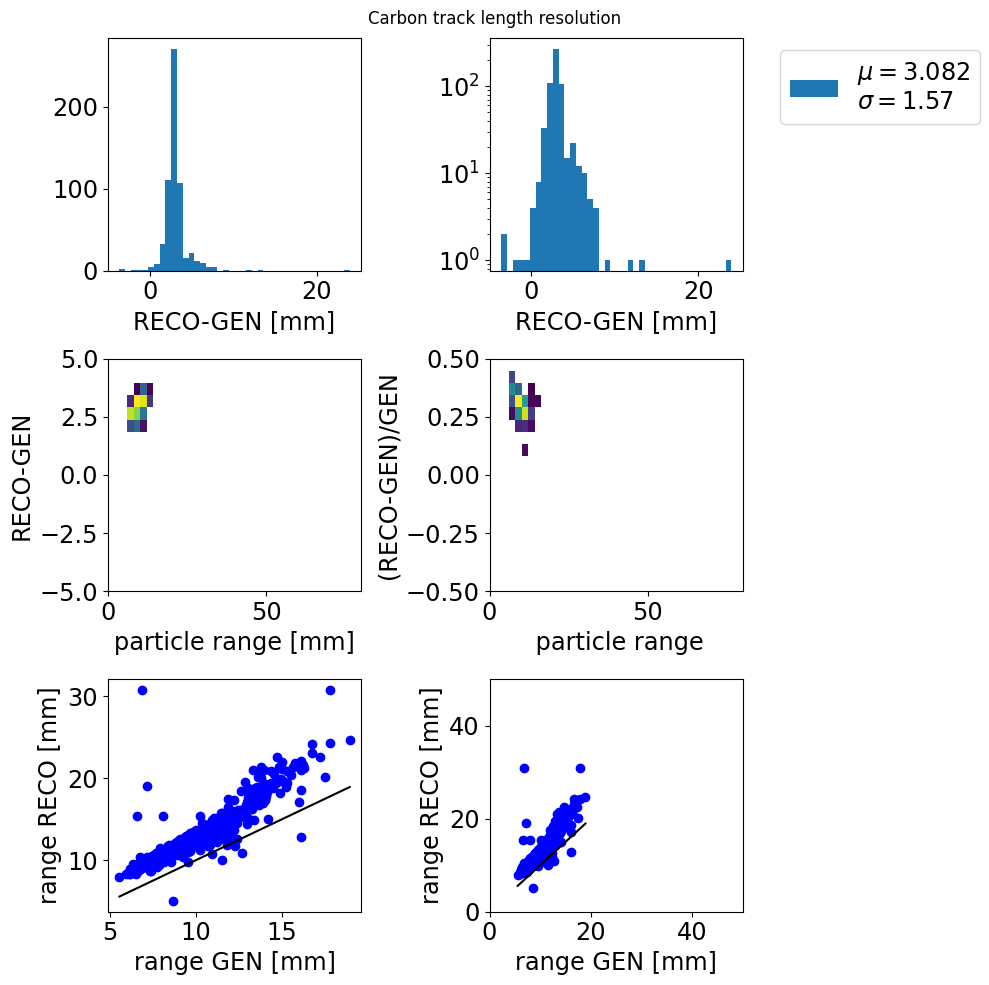

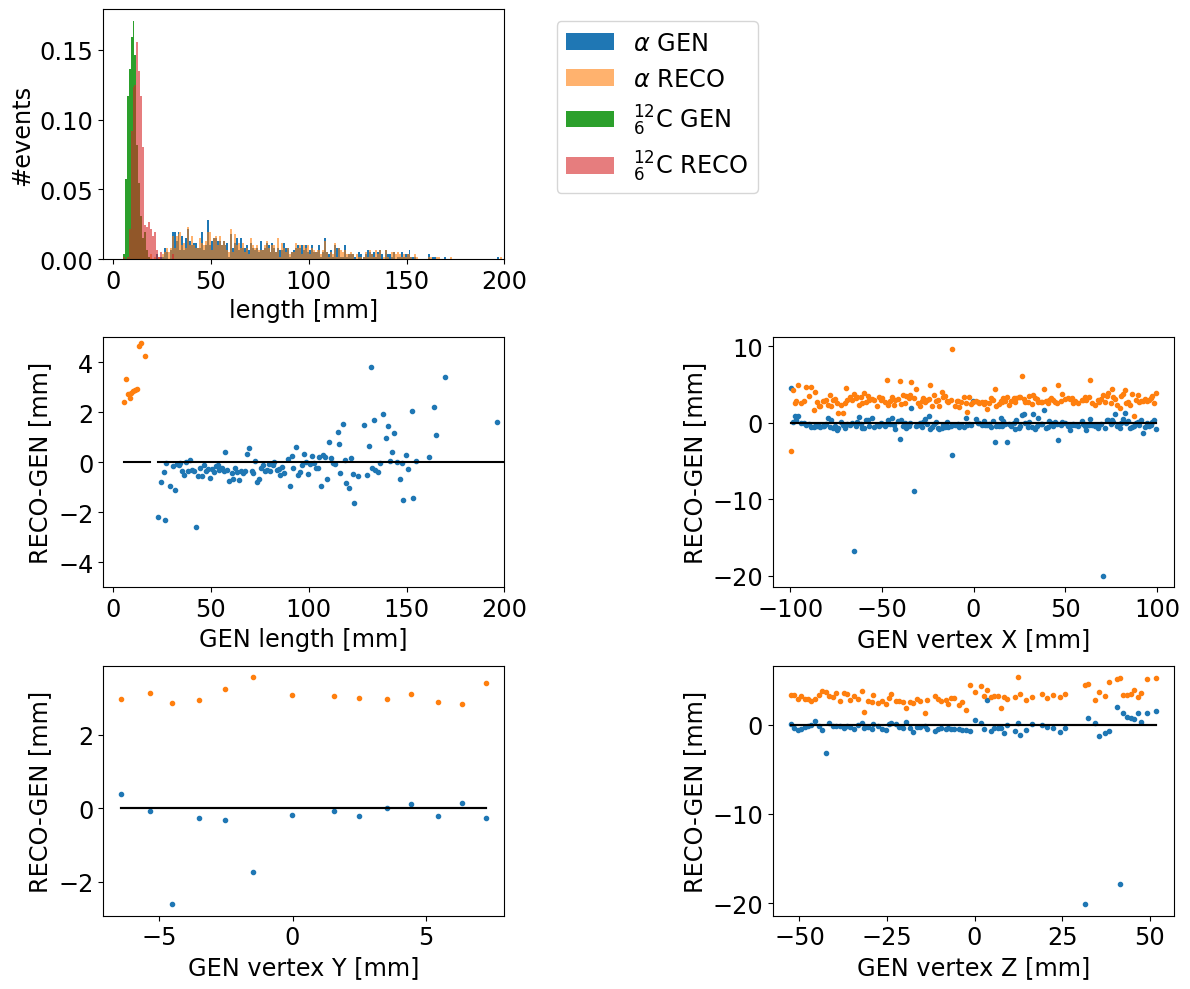

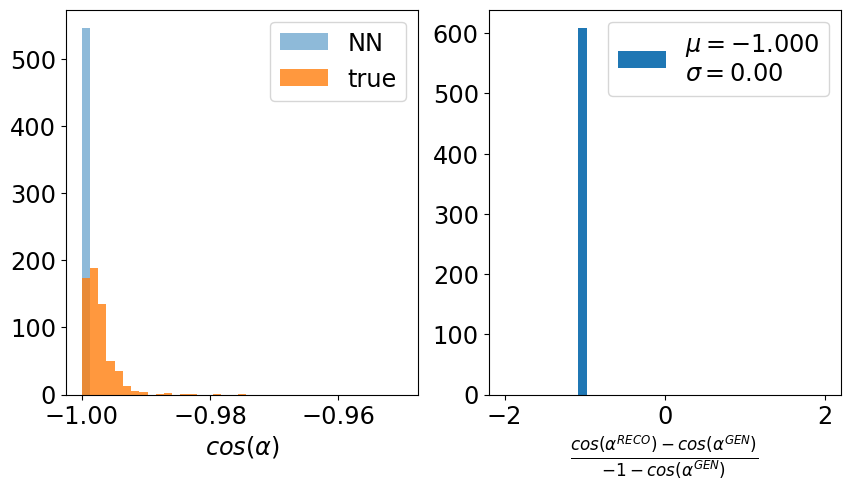

In [3]:
import plotting_functions as plf
importlib.reload(plf)

#plf.controlPlots(df)
plf.plotEndPointRes(df=df, edge="Vtx")
plf.plotEndPointRes(df=df, edge="Alpha")
plf.plotEndPointRes(df=df, edge="Carbon")

plf.plotLengthPull(df, partName="Alpha")
plf.plotLengthPull(df, partName="Carbon")
plf.plotLengthPullEvolution(df)
plf.plotOpeningAngleCos(df)

### Resolution plots for filtered dataset

/home/akalinow/scratch/ELITPC/TPCReco/PythonAnalysis/python/plotting_functions.py:191: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["d"+partName+"_sim"] = d_sim
/home/akalinow/scratch/ELITPC/TPCReco/PythonAnalysis/python/plotting_functions.py:192: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["d"+partName+"_reco"] = d_reco
/home/akalinow/scratch/ELITPC/TPCReco/PythonAnalysis/python/plotting_functions.py:193: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
T

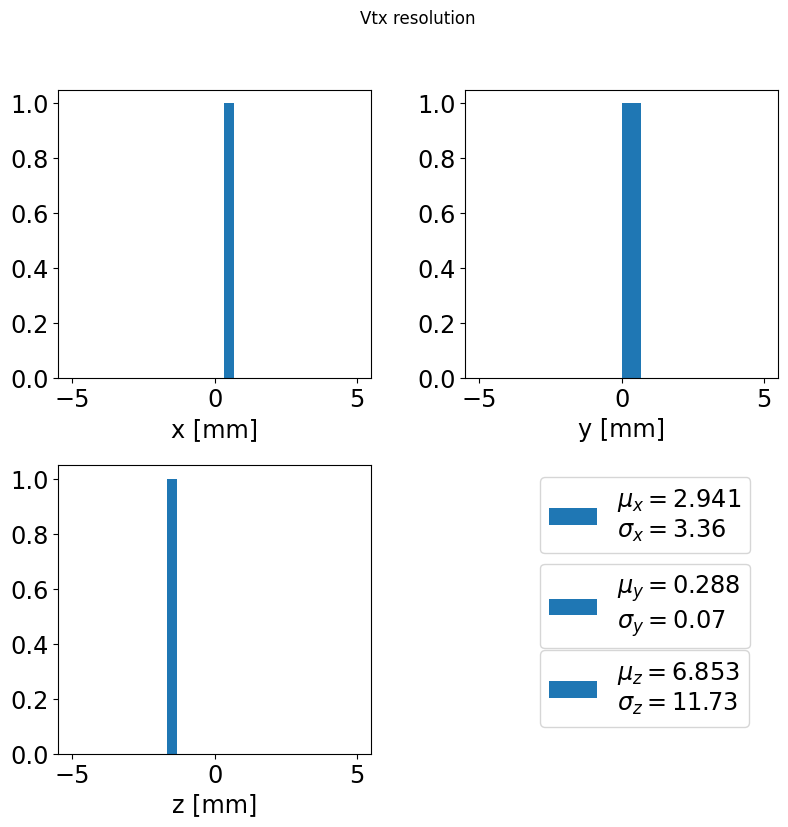

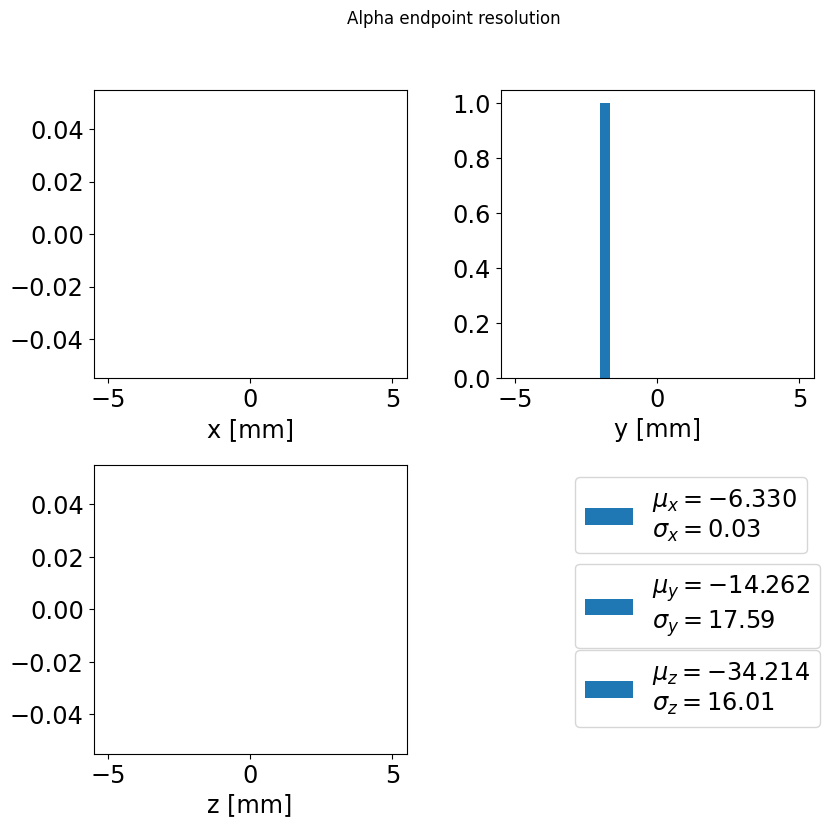

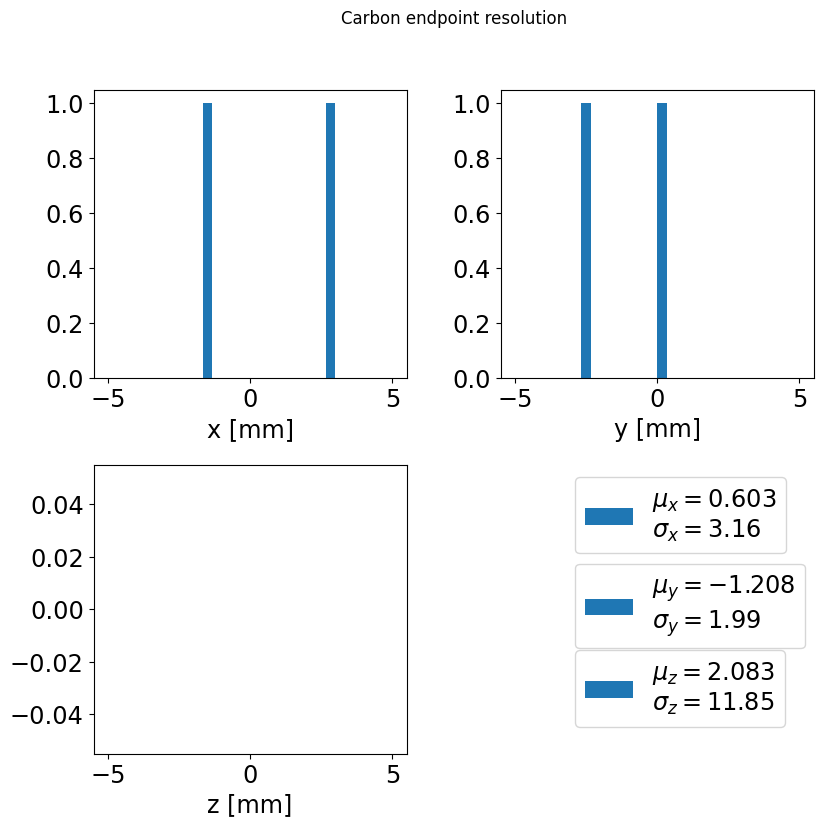

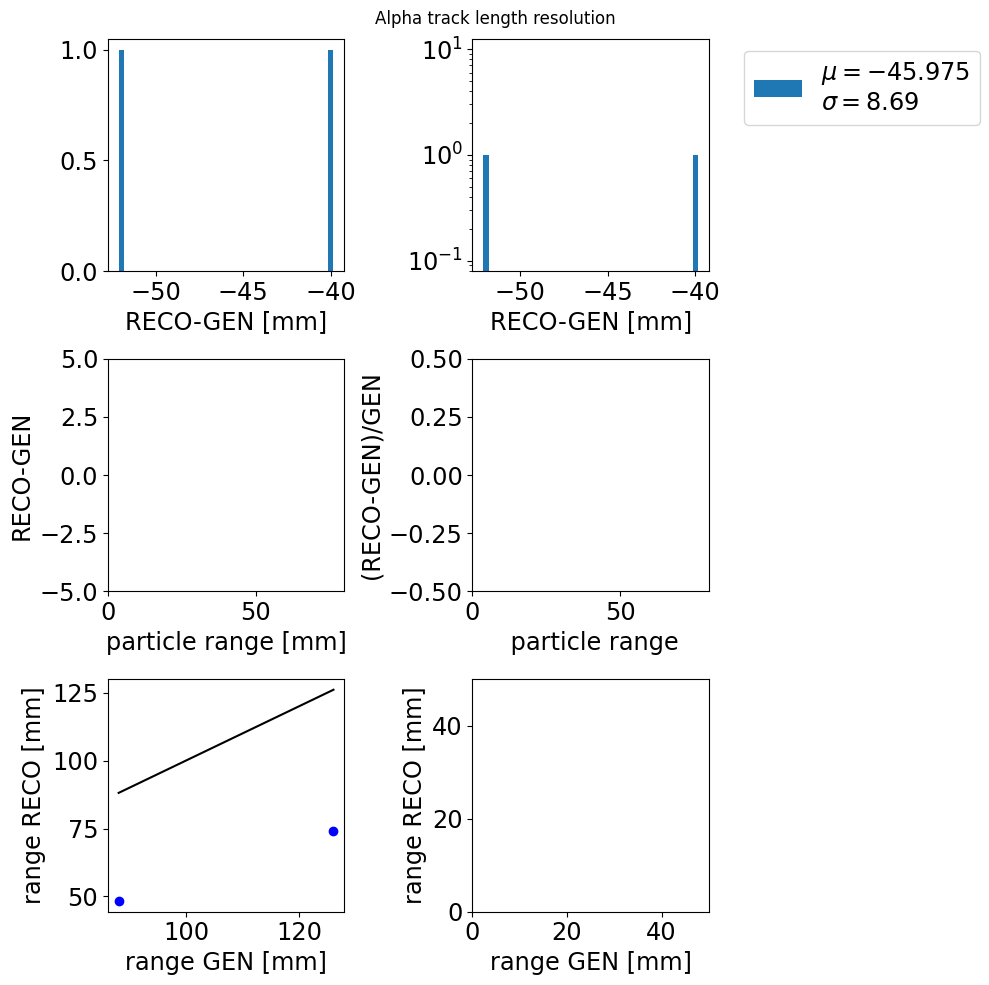

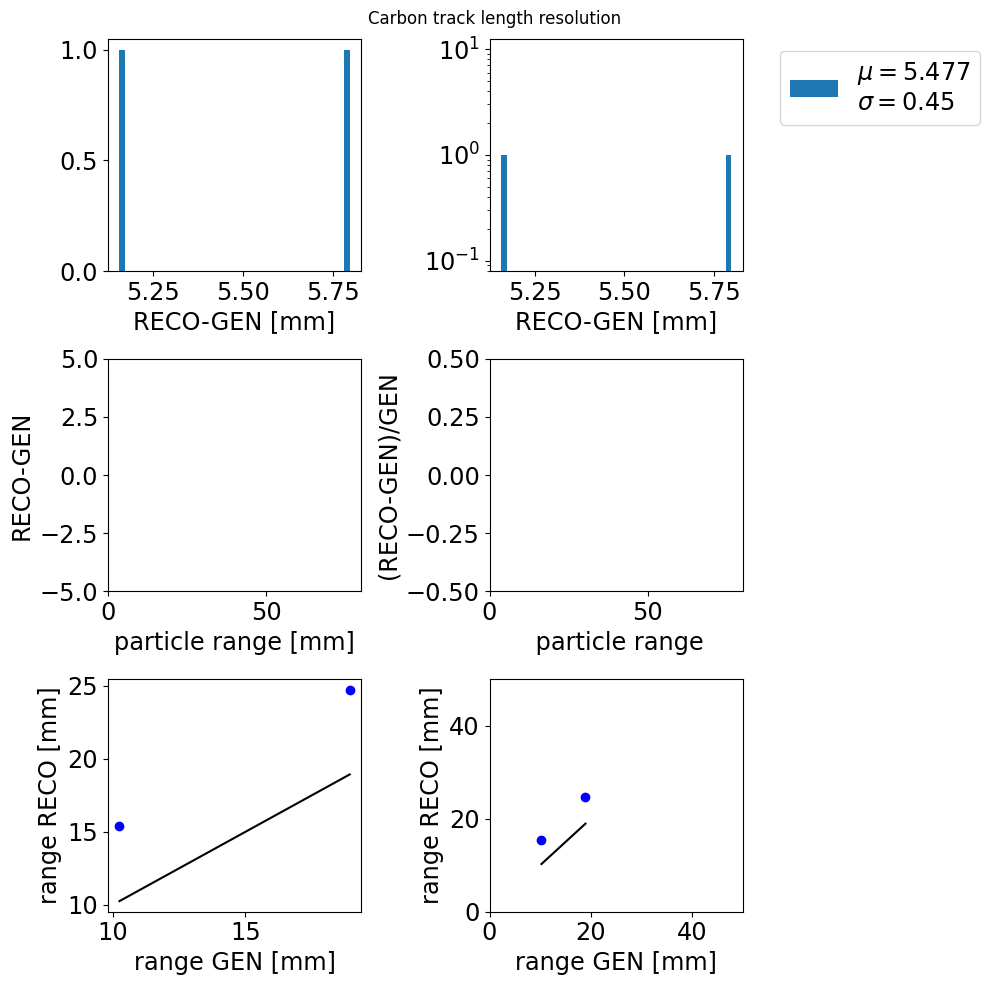

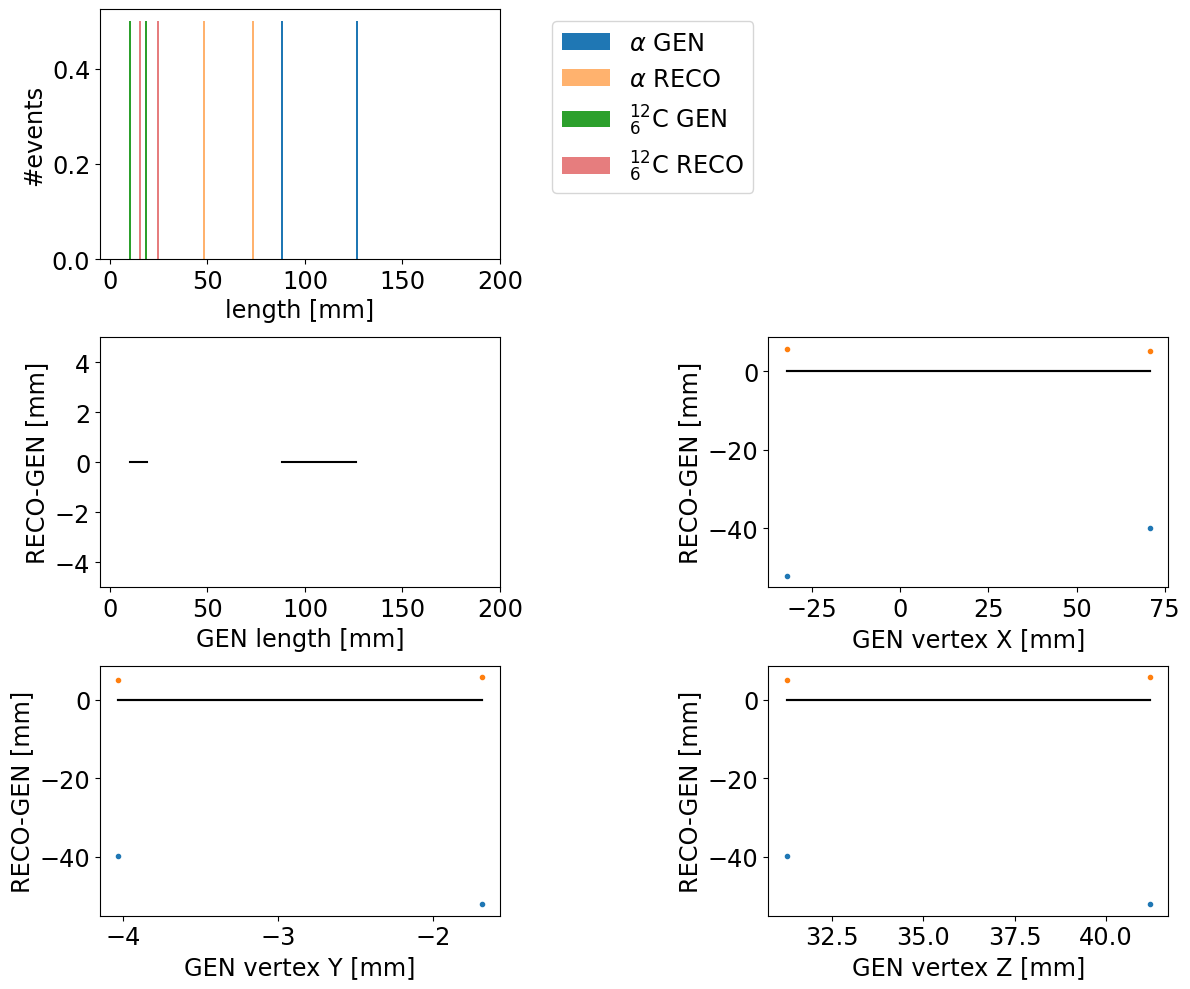

In [4]:
mask = (df["pullAlpha"]<-20)*(np.abs(df["xAlpha_sim"])<100)*(np.abs(df["yAlpha_sim"])<90)

#plf.controlPlots(df[mask])
plf.plotEndPointRes(df=df[mask], edge="Vtx")
plf.plotEndPointRes(df=df[mask], edge="Alpha")
plf.plotEndPointRes(df=df[mask], edge="Carbon")

plf.plotLengthPull(df[mask], partName="Alpha")
plf.plotLengthPull(df[mask], partName="Carbon")
plf.plotLengthPullEvolution(df[mask])




## 2D plots 

KeyError: 'alphaRangeGen'

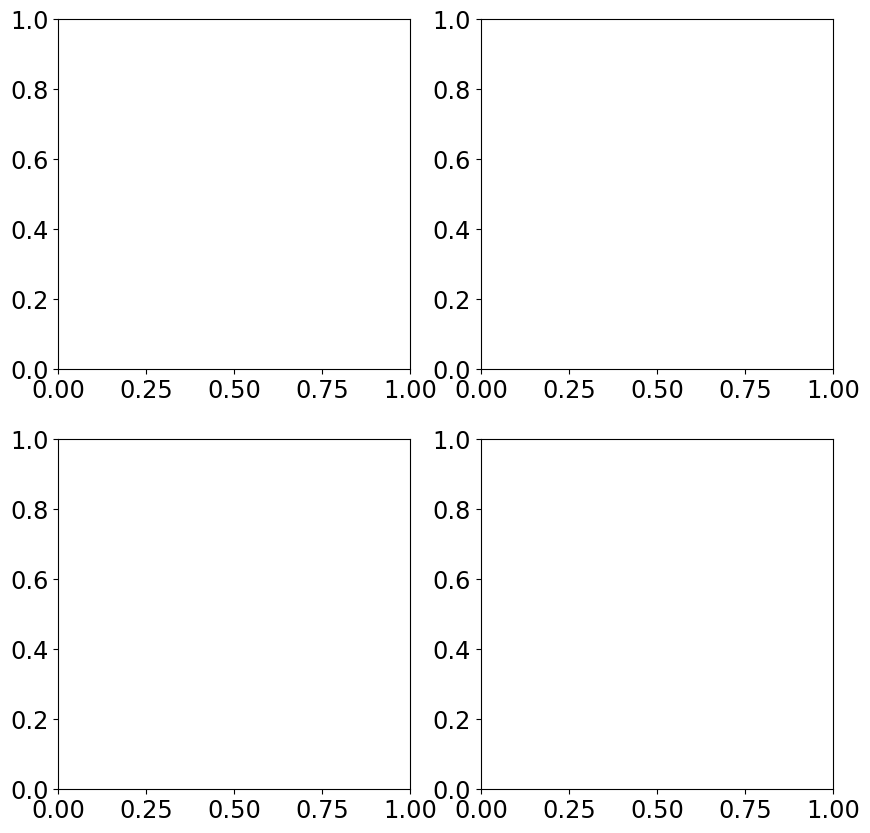

In [5]:
params = {'legend.fontsize': 'xx-large',
          'figure.figsize': (14, 10),
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large',
         #'xticks':'major_ticks_top'
         }

plt.rcParams.update(params)


fig, axes = plt.subplots(2, 2, figsize = (10, 10))

'''
trackTree->Draw("(alphaRangeReco-alphaRangeGen)/alphaRangeGen:alphaRangeGen>>hRangeResVsRangeGen(21,0, 70,  41,-0.5,0.5)","","goff");
trackTree->Draw("(alphaRangeReco-alphaRangeGen)/alphaRangeGen:cosThetaGen>>hRangeResVsCosTheta(21,-1, 1,  41,-0.5,0.5)","","goff");
trackTree->Draw("abs(cosThetaReco)-abs(cosThetaGen):cosThetaGen>>hCosThetaResVsCosTheta(21,-1, 1,  41,-0.5,0.5)","","goff");
trackTree->Draw("asin(sin(phiReco-phiGen)):cosThetaGen>>hPhiResVsCosTheta(21,-1, 1,  41,-0.5,0.5)","","goff");
trackTree->Draw("(chargeReco-chargeGen)/chargeGen:cosThetaGen>>hChargeResVsCosTheta(21,-1, 1,  41,-0.5,0.5)","","goff");
'''

x = df["alphaRangeGen"]
y = df.eval("(alphaRangeReco -alphaRangeGen)/alphaRangeGen")
xBins = np.linspace(0,60,20)
yBins = np.linspace(-0.5,0.5,20)
axes[0,0].hist2d(x, y, bins=(xBins, yBins), cmin=10, label="length")
axes[0,0].set_xlabel(r'$\alpha~range [mm]$')
axes[0,0].set_ylabel(r'$\frac{RECO-GEN}{GEN}$')

x = df["cosThetaGen"]
xBins = np.linspace(-1,1,20)
yBins = np.linspace(-0.5,0.5,20)
axes[0,1].hist2d(x, y, bins=(xBins, yBins), cmin=10, label="length")
axes[0,1].set_xlabel(r'$\cos(\theta)$')
axes[0,1].set_ylabel(r'$\frac{RECO-GEN}{GEN}$')

x = df["phiGen"]
xBins = np.linspace(-np.pi,np.pi,20)
yBins = np.linspace(-0.5,0.5,20)
axes[1,0].hist2d(x, y, bins=(xBins, yBins), cmin=10, label="length")
axes[1,0].set_xlabel(r'$\varphi$')
axes[1,0].set_ylabel(r'$\frac{RECO-GEN}{GEN}$')

x = df["dEdxFitChi2"]
xBins = np.linspace(x.min(),x.median(),20)
yBins = np.linspace(-0.5,0.5,20)
axes[1,1].hist2d(x, y, bins=(xBins, yBins), cmin=10, label="length")
axes[1,1].set_xlabel(r'$\frac{dE}{dx}$ fit loss func.')
axes[1,0].set_ylabel(r'$\frac{RECO-GEN}{GEN}$')

plt.subplots_adjust(bottom=0.15, left=0.05, right=0.95, wspace=0.35, hspace=0.3)
#plt.savefig("fig_png/2D_plots.png", bbox_inches="tight")

In [ ]:
simDataset = tf.data.Dataset.load('SimEvent_Track3D_TwoProng_gun_MC', compression="GZIP")

import plotting_functions as plf
importlib.reload(plf)

item = next(iter(simDataset.batch(1)))
plf.plotEvent(item, model=None)